# MSc. in Analytics and AI, 2025-27, ESMT Berlin

**Group Saturn**:
- Nazmil Ashraf
- Yuyan Yang
- Yu Hsun Fang
- Botond-Vilmos Nagy

# Group Project

## Objective
In this project, we utilized our skills to :
- collect data through multiple APIs and open source datasets, for both quantitative and qualitative data
- merge data from different sources
- describe and analyse datasets
- uncover patterns, insights
- calculate aggregated measures, statistics
- create compelling data visualisations
- write clean code
- tell a story and convince your audience


### Become a Business Manager

   - What kind of business do we run? What do we sell ? The choice of the business must be original and unique to your group.
   - How do we name our business?
   - When do we operate? Is it an all-year-round business or a seasonal one? If so, which seasons? Which months / weeks / days / hours of the day do we operate?
   - Where do we operate? In which countries / cities are we currently active ? Where do we want to develop in the future ? Determine where to set up your business stand based on weather conditions, local attractions, or events.
   - Which datasets will assist us in making our business the most successful?


## 01 - Getting Ready: first questions

We operate a power bank rental service that provides on-the-go charging solutions for smartphone/laptop users. Our company installs automated rental stations, which are similar to vending machines, where customers can easily rent and return power banks. These stations are strategically placed in U-Bahn stations, shopping malls, and other high-traffic areas across Berlin.

Our goal is to make charging convenient and accessible for both locals and tourists who are constantly on the move.

Our business name is Saturn PowerGo Berlin.

Saturn PowerGo Berlin is an all-year-round business since people need to charge their devices in every season. Our power bank stations operate 24/7, ensuring users can access them anytime—whether during morning commutes, shopping hours, or late-night travel.

We currently operate in Berlin, Germany, focusing on districts with high people flow such as:
Alexanderplatz, Potsdamer Platz, Mitte, etc. If the Berlin model proves successful, we plan to expand to other major German cities such as Munich or Hamburg.

Competitors data, Phone penetration rate and usage by age, Phone battery life, Tourists activities will assist us on making our business successful.

## 02 - Collect data from multiple APIs, the more the merrier

Integrated with as many APIs as we could:
- OpenWeatherMap API
- Google Maps,
- Kaggle,
- News API,


Each API provided different types of information. Chose the ones that best suit our scenario.

After collecting all the data we needed, we saved them.

### Installation AND Dependencies

In [ ]:
# ---  ---
# Run this cell once to ensure all necessary libraries are installed for reproducibility.

# Core data manipulation and API access
!pip install pandas requests

# For the Geo-spatial analysis (used later in the notebook)
!pip install geopandas contextily

# For accessing Kaggle data
!pip install kagglehub

### Popular places in Berlin

Using google maps API

In [19]:
import requests
import pandas as pd

GOOGLE_API_KEY = ""

# Berlin center coordinates
latitude = 52.5200
longitude = 13.4050

# Types that indicate HIGH foot traffic
PLACE_TYPES = ["transit_station", "tourist_attraction", "shopping_mall", "train_station", "university", "museum", "stadium", "park"]

all_results = []

for place_type in PLACE_TYPES:
    url = "https://maps.googleapis.com/maps/api/place/nearbysearch/json"
    params = {
        "location": f"{latitude},{longitude}",
        "radius": 10000,        # in meters
        "type": place_type,
        "key": GOOGLE_API_KEY
    }
    response = requests.get(url, params=params)
    data = response.json()

    for place in data.get("results", []):
        all_results.append({
            "name": place.get("name"),
            "address": place.get("vicinity"),
            "type": place_type,
            "rating": place.get("rating"),
            "user_ratings_total": place.get("user_ratings_total"),
            "lat": place["geometry"]["location"]["lat"],
            "lng": place["geometry"]["location"]["lng"]
        })

# Convert to DataFrame
df = pd.DataFrame(all_results)

# Rank by number of reviews (proxy for foot traffic)
df_sorted = df.sort_values(by="user_ratings_total", ascending=False)
df_sorted.to_csv("popular_places_berlin.csv", index=False)

df_sorted

,name,address,type,rating,user_ratings_total,lat,lng
37,Alexanderplatz,Berlin,tourist_attraction,4.3,233976.0,52.521981,13.413306
35,Checkpoint Charlie,"Friedrichstraße 43-45, Berlin",tourist_attraction,4.1,92488.0,52.507443,13.390391
33,Berlin Zoological Garden,"Hardenbergplatz 8, Berlin",tourist_attraction,4.5,71357.0,52.507830,13.339416
41,KaDeWe - Kaufhaus des Westens,"Tauentzienstraße 21-24, Berlin",shopping_mall,4.3,62640.0,52.501602,13.340993
28,East Side Gallery,"Mühlenstraße, Berlin",tourist_attraction,4.6,61894.0,52.505022,13.439695
...,...,...,...,...,...,...,...
91,Centre for British Studies (Humboldt-Universit...,"Anton-Wilhelm-Amo-Straße 60, Berlin",university,4.0,1.0,52.512259,13.387564
2,Schwarz & Schmiedel,"Ordensmeisterstraße 40, Berlin",transit_station,NaN,NaN,52.458630,13.395090
19,Irenenstr.,Germany,transit_station,NaN,NaN,52.509380,13.499520
135,Sportanlage Hertzbergplatz,"Weserstr. 122, Berlin-Bezirk Neukölln",stadium,NaN,NaN,52.477094,13.451611


### Phone specs

Link: https://www.kaggle.com/datasets/beridzeg45/gsmarena-smartphones

In [20]:
import kagglehub
import pandas as pd
import re
import os

# Download latest version
path = kagglehub.dataset_download("beridzeg45/gsmarena-smartphones")

csv_regex = re.compile(r".*\.csv$")
csv_files = [f for f in os.listdir(path) if csv_regex.match(f)]
dataframes = {f: pd.read_csv(os.path.join(path, f)) for f in csv_files}

# save every file to the curent directory
for filename, df in dataframes.items():
    df.to_csv(filename, index=False)

## 03 - Collect data from open source data sources

The dataset aligned with our end-goal and served its purpose.

At the end of this step, we have collected both quantitative and qualitative data.

### Competitors: locations of Competitor's stations
https://docs.google.com/spreadsheets/d/1YMs7navlSx6CSB3gNoOQxxFHBtnWC5WUAxce5_HpHlw/edit?usp=sharing
(This dataset is made from manually collected data from a competitors app.)

### Phone usage in the Europe
https://ec.europa.eu/eurostat/databrowser/view/isoc_ci_im_i/default/table?lang=en&category=isoc.isoc_i.isoc_i_h

### Phone brands sold in Europe
https://gs.statcounter.com/vendor-market-share/mobile/europe

### Device analyser papers
https://www.cl.cam.ac.uk/~acr31/pubs/wagner-bigdata.pdf
https://www.cl.cam.ac.uk/~acr31/pubs/wagner-understanding.pdf

### Tourism datasets
https://about.visitberlin.de/en/materialien/toolkit/tourism-stats

## 04 - Data cleaning and processing

In order to make data-driven decisions, we cleaned the collected data, filled missing values, merged datasets


Organized the dataset into a structured format, such as a CSV files, and a table where each row represents the achieved data.

In [ ]:
# Necessary imports
import pandas as pd
import os
import googlemaps
from math import radians, sin, cos, sqrt, atan2

#### Use this cell for Google Colab

In [ ]:
# Comment the following lines if running notebook locally
# drive_path = "/content/drive"
# project_path = os.path.join(drive_path, "MyDrive/Colab Notebooks/Group Project")
# data_path = os.path.join(project_path, "data")

# from google.colab import drive
# drive.mount('/content/drive')

#### Use this cell for local developing

In [ ]:
# Uncomment the folowing lines if running notebook in Google Colab
project_path = "."
data_path = os.path.join(project_path, "data")

In [ ]:
# Create directories if they don't exist
os.makedirs(os.path.join(data_path, "phones"), exist_ok=True)
os.makedirs(os.path.join(data_path, "people"), exist_ok=True)
os.makedirs(os.path.join(data_path, "competitors"), exist_ok=True)
os.makedirs(os.path.join(data_path, "popular_places_competitors_link"), exist_ok=True)

### Ensure that you have the following files ready prior to running the notebook:
- data/competitors/competitors.csv (export this as csv: https://docs.google.com/spreadsheets/d/1YMs7navlSx6CSB3gNoOQxxFHBtnWC5WUAxce5_HpHlw/edit?usp=sharing)
- data/phones/units_sold_eu.csv (select germany and download csv from here: https://gs.statcounter.com/vendor-market-share/mobile/germany)
- data/phones/phone_specs.csv (use the dataset downloaded in the previous exercise: https://www.kaggle.com/datasets/beridzeg45/gsmarena-smartphones)
- data/people/popular_places_berlin.csv (from the previous exercise, from Google Maps API)
- data/people/tourism_berlin.csv (gathered from https://about.visitberlin.de/en/materialien/toolkit/tourism-stats, export the excel available at https://docs.google.com/spreadsheets/d/1BBJ0913gHG5-wepsy_9jjpUrpP3FwMFYDTI2x8Y63Sw/edit?usp=sharing to csv)
##### In every case the file names should be as stated in the list!

### 1. Phone specifications

In [ ]:
phone_specs_dataframe = pd.read_csv(os.path.join(data_path, "phones", "phone_specs.csv"))
phone_specs_dataframe.head()

,URL,Brand,Model,Hits,Became Fan,Launch Expected Year,Height (mm),Width (mm),Thickness (mm),Body_Weight (g),...,Display Size (inches),Screen_to_Body_Ratio (%),RAM (GB),Main Camera_Single (MP),Selfie camera_Single (MP),Sound_3.5mm jack,Comms_Bluetooth,Comms_NFC,Battery_Capacity (mAh),Price in USD
0,https://www.gsmarena.com/acer_betouch_e400-315...,Acer,Acer beTouch E400,315311,12,2010.0,115.0,59.3,12.0,125.0,...,3.20,44.7,0.25,3.15,NaN,1.0,2.0,4161.0,1090.0,106.4
1,https://www.gsmarena.com/xiaomi_mi_1s-4929.php,Xiaomi,Xiaomi Mi 1S,2084613,163,2012.0,125.0,63.0,11.9,149.0,...,4.00,56.0,1.00,8.00,2.0,1.0,2.1,NaN,1930.0,245.1
2,https://www.gsmarena.com/lg_joy-7054.php,LG,LG Joy,607924,23,2015.0,122.7,64.0,11.9,128.0,...,4.00,58.0,0.50,5.00,NaN,1.0,4.0,NaN,1900.0,99.9
3,https://www.gsmarena.com/blackberry_evolve_x-9...,BlackBerry,BlackBerry Evolve X,1595494,118,2018.0,159.1,76.8,8.8,170.0,...,5.99,75.8,6.00,NaN,16.0,1.0,5.0,NaN,4000.0,413.0
4,https://www.gsmarena.com/samsung_i929_galaxy_s...,Samsung,Samsung I929 Galaxy S II Duos,2750554,40,2011.0,129.8,68.9,9.7,138.0,...,4.52,65.0,1.00,8.00,2.0,1.0,3.0,NaN,1800.0,264.1


In [ ]:
phone_specs_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7127 entries, 0 to 7126
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   URL                        7127 non-null   object 
 1   Brand                      7127 non-null   object 
 2   Model                      7127 non-null   object 
 3   Hits                       7127 non-null   int64  
 4   Became Fan                 7127 non-null   int64  
 5   Launch Expected Year       7127 non-null   float64
 6   Height (mm)                6875 non-null   float64
 7   Width (mm)                 6875 non-null   float64
 8   Thickness (mm)             6875 non-null   float64
 9   Body_Weight (g)            6571 non-null   float64
 10  Display_Type               7127 non-null   object 
 11  Pixels_X                   7120 non-null   float64
 12  Pixels_Y                   7116 non-null   float64
 13  Display Size (inches)      7127 non-null   float

In [ ]:
# Getting the essential columns from the dataset [Brand, Model, Battery capacity and Pricing]
phone_specs_dataframe = phone_specs_dataframe[['Brand', 'Model', 'Battery_Capacity (mAh)', 'Price in USD']]

# Rename the columns
phone_specs_dataframe.columns = ['brand', 'model', 'battery', 'price']

# Convert brand and model names to lowercase
phone_specs_dataframe.brand = phone_specs_dataframe.brand.str.lower()
phone_specs_dataframe.model = phone_specs_dataframe.model.str.lower()
phone_specs_dataframe.head()

,brand,model,battery,price
0,acer,acer betouch e400,1090.0,106.4
1,xiaomi,xiaomi mi 1s,1930.0,245.1
2,lg,lg joy,1900.0,99.9
3,blackberry,blackberry evolve x,4000.0,413.0
4,samsung,samsung i929 galaxy s ii duos,1800.0,264.1


In [ ]:
# Drop rows with "battery" missing
phone_specs_dataframe = phone_specs_dataframe.dropna(subset=['battery'])
phone_specs_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6904 entries, 0 to 7126
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   brand    6904 non-null   object 
 1   model    6904 non-null   object 
 2   battery  6904 non-null   float64
 3   price    6904 non-null   float64
dtypes: float64(2), object(2)
memory usage: 269.7+ KB


In [ ]:
# Save phone specs as a cleaned csv
phone_specs_dataframe.to_csv(os.path.join(data_path, "phones", "phone_specs_cleaned.csv"), index=False)

### 2. Phone brand market share

In [ ]:
units_sold_dataframe = pd.read_csv(os.path.join(data_path, "phones", "units_sold_eu.csv"))
units_sold_dataframe.head()

,Date,Apple,Samsung,Xiaomi,Unknown,Huawei,Google,Motorola,Oppo,Realme,...,Nothing,TCL,Asus,Alcatel,Itel,Fairphone,CAT,T-Mobile,HTC,Other
0,2024-09,34.10,31.74,13.89,3.33,3.03,1.99,2.31,2.47,1.46,...,0.11,0.11,0.09,0.09,0.05,0.03,0.04,0.01,0.02,0.11
1,2024-10,36.50,31.14,12.95,3.27,2.82,2.08,2.21,2.36,1.31,...,0.11,0.10,0.08,0.08,0.05,0.03,0.03,0.01,0.02,0.08
2,2024-11,33.05,33.21,13.83,3.36,2.79,2.10,2.33,2.49,1.32,...,0.11,0.10,0.08,0.08,0.05,0.03,0.03,0.01,0.02,0.09
3,2024-12,33.36,33.16,13.54,3.51,2.74,2.13,2.37,2.36,1.32,...,0.12,0.09,0.08,0.07,0.05,0.04,0.03,0.01,0.02,0.08
4,2025-01,33.92,33.02,13.27,3.32,2.60,2.29,2.46,2.28,1.35,...,0.12,0.09,0.08,0.07,0.04,0.03,0.03,0.01,0.01,0.07


In [ ]:
# split Date column into Year and Month columns
units_sold_dataframe[['Year', 'Month']] = units_sold_dataframe['Date'].str.split('-', expand=True)
units_sold_dataframe = units_sold_dataframe.drop(columns=['Date'])
units_sold_dataframe.head()

,Apple,Samsung,Xiaomi,Unknown,Huawei,Google,Motorola,Oppo,Realme,Honor,...,Asus,Alcatel,Itel,Fairphone,CAT,T-Mobile,HTC,Other,Year,Month
0,34.10,31.74,13.89,3.33,3.03,1.99,2.31,2.47,1.46,0.99,...,0.09,0.09,0.05,0.03,0.04,0.01,0.02,0.11,2024,09
1,36.50,31.14,12.95,3.27,2.82,2.08,2.21,2.36,1.31,0.96,...,0.08,0.08,0.05,0.03,0.03,0.01,0.02,0.08,2024,10
2,33.05,33.21,13.83,3.36,2.79,2.10,2.33,2.49,1.32,1.12,...,0.08,0.08,0.05,0.03,0.03,0.01,0.02,0.09,2024,11
3,33.36,33.16,13.54,3.51,2.74,2.13,2.37,2.36,1.32,1.13,...,0.08,0.07,0.05,0.04,0.03,0.01,0.02,0.08,2024,12
4,33.92,33.02,13.27,3.32,2.60,2.29,2.46,2.28,1.35,1.16,...,0.08,0.07,0.04,0.03,0.03,0.01,0.01,0.07,2025,01


In [ ]:
# make the first columns Year and Month, and convert them to numeric type
cols = units_sold_dataframe.columns.tolist()
cols = cols[-2:] + cols[:-2]
units_sold_dataframe = units_sold_dataframe[cols]
units_sold_dataframe[['Year', 'Month']] = units_sold_dataframe[['Year', 'Month']].astype(int)
units_sold_dataframe.head()

,Year,Month,Apple,Samsung,Xiaomi,Unknown,Huawei,Google,Motorola,Oppo,...,Nothing,TCL,Asus,Alcatel,Itel,Fairphone,CAT,T-Mobile,HTC,Other
0,2024,9,34.10,31.74,13.89,3.33,3.03,1.99,2.31,2.47,...,0.11,0.11,0.09,0.09,0.05,0.03,0.04,0.01,0.02,0.11
1,2024,10,36.50,31.14,12.95,3.27,2.82,2.08,2.21,2.36,...,0.11,0.10,0.08,0.08,0.05,0.03,0.03,0.01,0.02,0.08
2,2024,11,33.05,33.21,13.83,3.36,2.79,2.10,2.33,2.49,...,0.11,0.10,0.08,0.08,0.05,0.03,0.03,0.01,0.02,0.09
3,2024,12,33.36,33.16,13.54,3.51,2.74,2.13,2.37,2.36,...,0.12,0.09,0.08,0.07,0.05,0.04,0.03,0.01,0.02,0.08
4,2025,1,33.92,33.02,13.27,3.32,2.60,2.29,2.46,2.28,...,0.12,0.09,0.08,0.07,0.04,0.03,0.03,0.01,0.01,0.07


In [ ]:
# Save cleaned phone specifications data
units_sold_dataframe.to_csv(os.path.join(data_path, "phones", "units_sold_eu_cleaned.csv"), index=False)

### 3. ICT Usage (Phones and portable devices)

In [ ]:
ICT_USAGE_DATA_URL = "https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/isoc_ci_im_i/1.0?compress=false&format=csvdata&formatVersion=1.0&lang=en&labels=label_only"

ict_usage_dataframe = pd.read_csv(ICT_USAGE_DATA_URL)
# Save raw dataset straight away
ict_usage_dataframe.to_csv(os.path.join(data_path, "phones", "usage_eu.csv"), index=False)

#### ALTERNATIVE (if for some reason the internet connection is slow and connection gets reset):
- go to "https://ec.europa.eu/eurostat/databrowser/view/isoc_ci_im_i/default/table?lang=en&category=isoc.isoc_i.isoc_i_h"
- click on download button (between Share/bookmark and Help)
- choose "SDMX-CSV 1.0 (.csv)" for file format
- choose "Full dataset" for data scope
- make sure that "Compress file (.gzip)" is NOT checked
- click on "Download"
- move the downloaded file to data/phones and rename it to "usage_eu.csv"

In [ ]:
# Uncomment the lines below if you downloaded the dataset manually

ict_usage_dataframe = pd.read_csv(os.path.join(data_path, "phones", "usage_eu.csv"))

In [ ]:
ict_usage_dataframe.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,indic_is,Information society indicator,unit,Unit of measure,ind_type,...,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:ISOC_CI_IM_I(1.0),Individuals - mobile internet access (2011-2019),A,Annual,I_IUHD,Individuals used any handheld device to access...,PC_IND,Percentage of individuals,CB_EU_FOR,...,AT,Austria,2012,NaN,34.11,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:ISOC_CI_IM_I(1.0),Individuals - mobile internet access (2011-2019),A,Annual,I_IUHD,Individuals used any handheld device to access...,PC_IND,Percentage of individuals,CB_EU_FOR,...,BE,Belgium,2012,NaN,31.61,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:ISOC_CI_IM_I(1.0),Individuals - mobile internet access (2011-2019),A,Annual,I_IUHD,Individuals used any handheld device to access...,PC_IND,Percentage of individuals,CB_EU_FOR,...,BG,Bulgaria,2012,NaN,NaN,NaN,u,low reliability,NaN,NaN
3,dataflow,ESTAT:ISOC_CI_IM_I(1.0),Individuals - mobile internet access (2011-2019),A,Annual,I_IUHD,Individuals used any handheld device to access...,PC_IND,Percentage of individuals,CB_EU_FOR,...,CY,Cyprus,2012,NaN,16.34,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:ISOC_CI_IM_I(1.0),Individuals - mobile internet access (2011-2019),A,Annual,I_IUHD,Individuals used any handheld device to access...,PC_IND,Percentage of individuals,CB_EU_FOR,...,CZ,Czechia,2012,NaN,NaN,NaN,u,low reliability,NaN,NaN


In [ ]:
# Select only relevant columns
column_filter = ["indic_is", "unit", "ind_type", "geo", "TIME_PERIOD", "OBS_VALUE", "OBS_FLAG"]
ict_usage_dataframe = ict_usage_dataframe[column_filter]

In [ ]:
# Specify new column names
new_column_names = {
    "indic_is": "indicator",
    "unit": "unit",
    "ind_type": "indicator_type",
    "geo": "country",
    "TIME_PERIOD": "year",
    "OBS_VALUE": "value",
    "OBS_FLAG": "flag"
}
ict_usage_dataframe = ict_usage_dataframe.rename(columns=new_column_names)
ict_usage_dataframe.head()

,indicator,unit,indicator_type,country,year,value,flag
0,I_IUHD,PC_IND,CB_EU_FOR,AT,2012,34.11,NaN
1,I_IUHD,PC_IND,CB_EU_FOR,BE,2012,31.61,NaN
2,I_IUHD,PC_IND,CB_EU_FOR,BG,2012,NaN,u
3,I_IUHD,PC_IND,CB_EU_FOR,CY,2012,16.34,NaN
4,I_IUHD,PC_IND,CB_EU_FOR,CZ,2012,NaN,u


In [ ]:
# We'll fill the missing values in the 'value' and 'flag' columns using KNN
# first, we encode all columns to numeric values with label encoding
from sklearn.preprocessing import LabelEncoder

# create a copy of the dataframe to perform imputation on
ict_usage_dataframe_imputed = ict_usage_dataframe.copy()

# we will not encode 'value' and 'year' columns, since these are already numeric
columns_to_encode = list(set(ict_usage_dataframe_imputed.columns) - set(["value", "year"]))
print(columns_to_encode)

encoders = {}
# mark rows that originally had missing 'value' or 'flag' separately (for later analysis)
ict_usage_dataframe_imputed['value_missing'] = ict_usage_dataframe[['value']].isna().any(axis=1).astype(int)
ict_usage_dataframe_imputed['flag_missing'] = ict_usage_dataframe[['flag']].isna().any(axis=1).astype(int)

for col in columns_to_encode:
    le = LabelEncoder()
    mask = ict_usage_dataframe_imputed[col].notna()
    ict_usage_dataframe_imputed.loc[mask, col] = le.fit_transform(ict_usage_dataframe_imputed.loc[mask, col])
    ict_usage_dataframe_imputed[col] = ict_usage_dataframe_imputed[col].astype("float")
    encoders[col] = le
ict_usage_dataframe_imputed.head()

['flag', 'indicator', 'country', 'indicator_type', 'unit']


,indicator,unit,indicator_type,country,year,value,flag,value_missing,flag_missing
0,0.0,0.0,0.0,1.0,2012,34.11,NaN,0,1
1,0.0,0.0,0.0,3.0,2012,31.61,NaN,0,1
2,0.0,0.0,0.0,4.0,2012,NaN,2.0,1,0
3,0.0,0.0,0.0,6.0,2012,16.34,NaN,0,1
4,0.0,0.0,0.0,7.0,2012,NaN,2.0,1,0


In [ ]:
# fill missing values using KNN imputer
from sklearn.impute import KNNImputer

incomplete_columns = ["value", "flag"]
for col in incomplete_columns:
    ict_usage_dataframe_imputed[[col]] = KNNImputer(n_neighbors=5).fit_transform(ict_usage_dataframe_imputed[[col]])
ict_usage_dataframe_imputed.head()

,indicator,unit,indicator_type,country,year,value,flag,value_missing,flag_missing
0,0.0,0.0,0.0,1.0,2012,34.110000,1.248062,0,1
1,0.0,0.0,0.0,3.0,2012,31.610000,1.248062,0,1
2,0.0,0.0,0.0,4.0,2012,40.062466,2.000000,1,0
3,0.0,0.0,0.0,6.0,2012,16.340000,1.248062,0,1
4,0.0,0.0,0.0,7.0,2012,40.062466,2.000000,1,0


In [ ]:
# Revert the label encoding
for col in columns_to_encode:
    ict_usage_dataframe_imputed[col] = encoders[col].inverse_transform(round(ict_usage_dataframe_imputed[col].astype(int)))
ict_usage_dataframe_imputed.head()

,indicator,unit,indicator_type,country,year,value,flag,value_missing,flag_missing
0,I_IUHD,PC_IND,CB_EU_FOR,AT,2012,34.110000,bu,0,1
1,I_IUHD,PC_IND,CB_EU_FOR,BE,2012,31.610000,bu,0,1
2,I_IUHD,PC_IND,CB_EU_FOR,BG,2012,40.062466,u,1,0
3,I_IUHD,PC_IND,CB_EU_FOR,CY,2012,16.340000,bu,0,1
4,I_IUHD,PC_IND,CB_EU_FOR,CZ,2012,40.062466,u,1,0


In [ ]:
# save cleaned dataset
ict_usage_dataframe_imputed.to_csv(os.path.join(data_path, "phones", "usage_eu_cleaned.csv"), index=False)

### 4. Tourism in Berlin

In [ ]:
tourist_dataframe = pd.read_csv(os.path.join(data_path, "people", "tourism_berlin.csv"))
tourist_dataframe.head()

,Year,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,YTD,"12,731,640","12,966,347","13,502,552","13,963,345","4,947,581","5,128,587","10,426,316","12,086,441","12,717,390","8,102,800"
1,Monthly,"1,060,970","1,080,529","1,125,213","1,163,612","412,298","427,382","868,860","1,007,203","1,059,783","1,012,850"


In [ ]:
# transpose the dataframe so that columns should be Year, YTD, Monthly
tourist_dataframe = tourist_dataframe.T
tourist_dataframe.columns = tourist_dataframe.iloc[0]
tourist_dataframe = tourist_dataframe.iloc[1:].rename_axis('Year').reset_index()
tourist_dataframe.head()

Year,Year,YTD,Monthly
0,2016,"12,731,640","1,060,970"
1,2017,"12,966,347","1,080,529"
2,2018,"13,502,552","1,125,213"
3,2019,"13,963,345","1,163,612"
4,2020,"4,947,581","412,298"


In [ ]:
# rename columns to lowercase
tourist_dataframe.columns = [col.lower() for col in tourist_dataframe.columns]

# convert columns to numeric values
# first remove commas from the numbers
tourist_dataframe['ytd'] = tourist_dataframe['ytd'].str.replace(',', '')
tourist_dataframe['monthly'] = tourist_dataframe['monthly'].str.replace(',', '')
tourist_dataframe = tourist_dataframe.apply(pd.to_numeric)
tourist_dataframe.head()

,year,ytd,monthly
0,2016,12731640,1060970
1,2017,12966347,1080529
2,2018,13502552,1125213
3,2019,13963345,1163612
4,2020,4947581,412298


In [ ]:
# save cleaned dataset
tourist_dataframe.to_csv(os.path.join(data_path, "people", "tourism_berlin_cleaned.csv"), index=False)

### 5. Locations that already have competitors present
##### We used competitors.csv (manually gathered data) and popular_places_berlin.csv, to augment the popular places dataset with a new, boolean column, which indicates if our competitor is already present at that location or not.
##### We checked this with multiple proximity thresholds (in meters), to get a better undestanding of how close are their station dpending on how close we look.
##### We used the great-circle distance to determine if the competitor's stations and the most popular locations found by us with the Map API are "close enough".

In [ ]:
# API key and google maps client
GOOGLE_MAPS_API_KEY = ""
gmaps = googlemaps.Client(key=GOOGLE_MAPS_API_KEY)

In [ ]:
popular_places = pd.read_csv(os.path.join(data_path, "people", "popular_places_berlin.csv"))
competitors = pd.read_csv(os.path.join(data_path, "competitors", "competitors.csv"))

# we won't need the address, since google can provide much more accurate coordinates with lat/lng
competitors = competitors.dropna(subset=['Address'])

PROXIMITY_THRESHOLDS = [50, 100, 250, 500, 1000]  # meters

In [ ]:
competitor_coords = []
for idx, comp in competitors.iterrows():
    try:
        geocode_result = gmaps.geocode(comp['Address'])
        if geocode_result:
            lat = geocode_result[0]['geometry']['location']['lat']
            lng = geocode_result[0]['geometry']['location']['lng']
            competitor_coords.append({
                'name': comp['Name'],
                'address': comp['Address'],
                'lat': lat,
                'lng': lng
            })
    except Exception as e:
        print(f"Error geocoding {comp['Address']}: {e}")

competitors_with_coords = pd.DataFrame(competitor_coords)
competitors_with_coords.head()

,name,address,lat,lng
0,The Nubis,"Hermann-Elflein-Straße 10, 14467 Potsdam",52.400303,13.048852
1,Bft Shop Kladow,"Kladower Damm 332, 14089 Berlin",52.457660,13.149450
2,Edeka Zahl,"Fischerhüttenstr. 68, 14163 Berlin",52.442176,13.240343
3,Lady Discreet,"Streitstraße 16, 13587 Berlin",52.558401,13.208566
4,Kiez Kiosk Kerdi,"Westerwaldstraße 7, 13589 Berlin",52.549976,13.178489


In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance between two points 
    on the earth (specified in decimal degrees)
    Returns distance in meters
    """
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    
    r = 6371000
    
    return r * c

def check_competitor_nearby_optimized(pop_lat, pop_lng, threshold):
    """
    Check if any competitor is within threshold distance
    Uses pre-geocoded competitor coordinates
    """
    for _, comp in competitors_with_coords.iterrows():
        distance = haversine_distance(pop_lat, pop_lng, comp['lat'], comp['lng'])
        if distance <= threshold:
            return True
    return False

In [ ]:
original_columns = popular_places.columns
for threshold in PROXIMITY_THRESHOLDS:
    column_name = f'has_competitor_{threshold}m'
    
    # compute flag for this threshold
    popular_places[column_name] = popular_places.apply(
        lambda row: check_competitor_nearby_optimized(row['lat'], row['lng'], threshold),
        axis=1
    )

    # save only original columns plus this threshold flag
    cols_to_save = list(original_columns) + [column_name] if column_name not in original_columns else list(original_columns)
    cols_to_save = [c for c in cols_to_save if c in popular_places.columns]

    filename = f"popular_places_berlin_{threshold}m.csv"
    popular_places[cols_to_save].copy().to_csv(os.path.join(data_path, "popular_places_competitors_link", filename), index=False)

popular_places.to_csv(os.path.join(data_path, "popular_places_competitors_link", "popular_places_berlin_all_thresholds.csv"), index=False)

## 05 - Compute relevant statistics

Computed descriptive statistics that informed us about the future and enabled us to answer the questions that helped achieve our end goal.


### 1. Grouping the Phone Specs dataset to estimate Average Battery Capacity

In [ ]:
# group the phone specs dataset by brands to estimate the average battery capacity (and the price additionally) of each phone brand
phone_specs_dataframe.groupby('brand').describe()

battery                                                             \
          count         mean          std     min     25%     50%      75%   
brand                                                                        
acer       70.0  2067.428571   977.763546   970.0  1350.0  1580.0  2415.00   
alcatel   179.0  2084.636872  1043.530232   400.0  1300.0  2000.0  2880.00   
allview    75.0  2486.400000   995.648152   800.0  1775.0  2200.0  3025.00   
amazon      5.0  3194.000000   737.685570  2400.0  2980.0  2980.0  3210.00   
apple      18.0  1832.666667   571.204301  1220.0  1423.0  1592.0  1925.25   
...         ...          ...          ...     ...     ...     ...      ...   
xolo       49.0  2168.979592   635.591080  1400.0  1800.0  2100.0  2400.00   
yezz       19.0  3407.894737  1816.610332  1350.0  2000.0  2600.0  4500.00   
yota        3.0  2533.333333   750.555350  1800.0  2150.0  2500.0  2900.00   
yu          9.0  2803.333333   770.129859  2000.0  2230.0  2500.0  3000.00   
zte       257.0  3216.167315  1273.131213   500.0  2200.0  3000.0  4200.00   

                 price                                                  \
            max  count        mean         std    min      25%     50%   
brand                                                                    
acer     5000.0   70.0  200.828571   85.965782   88.8  130.000  191.65   
alcatel  5000.0  179.0  162.741341  116.650595   22.2   83.000  139.00   
allview  6000.0   75.0  235.752000  134.353460   25.8  131.000  212.80   
amazon   4400.0    5.0  127.700000   63.947596   55.5   79.100  124.30   
apple    2915.0   18.0  301.161111  138.820875  132.3  201.975  265.05   
...         ...    ...         ...         ...    ...      ...     ...   
xolo     4100.0   49.0  169.669388   59.806857   66.6  133.000  159.60   
yezz     9000.0   19.0  110.952632   65.379579   56.0   70.800   89.60   
yota     3300.0    3.0  363.866667  171.552800  199.5  274.900  350.30   
yu       4000.0    9.0  178.833333  117.529613   77.7   99.900  144.30   
zte      6000.0  257.0  295.676654  213.348102   22.8  135.600  233.10   

                          
             75%     max  
brand                     
acer     254.025   452.2  
alcatel  200.050   824.6  
allview  305.900   625.1  
amazon   166.800   212.8  
apple    395.300   575.4  
...          ...     ...  
xolo     199.800   359.1  
yezz     120.750   295.0  
yota     446.050   541.8  
yu       199.800   466.2  
zte      377.600  1132.8  

[91 rows x 16 columns]

In [ ]:
# get the average battery capacity of a phone (and other statistics)
phone_specs_dataframe.describe()

,battery,price
count,6904.000000,6904.000000
mean,2741.170626,238.823899
std,1696.840641,192.634991
min,80.000000,10.500000
25%,1350.000000,118.800000
50%,2400.000000,189.000000
75%,4000.000000,296.700000
max,28000.000000,1974.000000


### 2. Phone brand market share in Germany to get the average battery capacity in Germany
If we get this, we can then approximate the value in Berlin.

In [ ]:
# phone brand market share statistics
units_sold_dataframe.iloc[:, 2:].describe()

,Apple,Samsung,Xiaomi,Unknown,Huawei,Google,Motorola,Oppo,Realme,Honor,...,Nothing,TCL,Asus,Alcatel,Itel,Fairphone,CAT,T-Mobile,HTC,Other
count,13.000000,13.00000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,...,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,34.436923,32.61000,12.510000,3.877692,2.506923,2.582308,2.418462,2.236154,1.256923,1.196923,...,0.112308,0.094615,0.067692,0.068462,0.052308,0.035385,0.026154,0.016154,0.013846,0.074615
std,1.157327,0.74773,0.995188,0.516884,0.278250,0.542527,0.113640,0.156020,0.103391,0.123044,...,0.005991,0.007763,0.015892,0.010682,0.007250,0.005189,0.006504,0.007679,0.005064,0.013301
min,33.050000,31.14000,11.090000,3.270000,2.090000,1.990000,2.210000,2.010000,1.120000,0.960000,...,0.100000,0.080000,0.050000,0.050000,0.040000,0.030000,0.020000,0.010000,0.010000,0.060000
25%,33.920000,32.42000,11.650000,3.360000,2.360000,2.130000,2.330000,2.090000,1.170000,1.130000,...,0.110000,0.090000,0.050000,0.060000,0.050000,0.030000,0.020000,0.010000,0.010000,0.070000
50%,34.130000,33.02000,12.520000,4.010000,2.430000,2.650000,2.430000,2.230000,1.290000,1.220000,...,0.110000,0.090000,0.080000,0.070000,0.050000,0.040000,0.030000,0.010000,0.010000,0.070000
75%,34.480000,33.14000,13.270000,4.210000,2.740000,2.770000,2.490000,2.360000,1.320000,1.290000,...,0.120000,0.100000,0.080000,0.070000,0.050000,0.040000,0.030000,0.020000,0.020000,0.080000
max,36.770000,33.21000,13.890000,4.680000,3.030000,4.050000,2.590000,2.490000,1.460000,1.340000,...,0.120000,0.110000,0.090000,0.090000,0.070000,0.040000,0.040000,0.030000,0.020000,0.110000


In [ ]:
"""
Now we select only those phone brands from phone specs that are also present in units sold, then
based on brand market share and average battery capacity by brand calculate the average battery capacity in germany.
If we get this, we can then approximate the value in Berlin.
"""
import numpy as np

# make copies
phone_specs_dataframe_copy = phone_specs_dataframe.copy()
units_sold_dataframe_copy = units_sold_dataframe.copy()

# capitalize brand
phone_specs_dataframe_copy['brand'] = phone_specs_dataframe_copy['brand'].str.strip().str.title()

# get list of brands in units sold
units_sold_brands = [col for col in units_sold_dataframe_copy.columns if col not in ['Year', 'Month']]

# filter the phone specs to only include brands present in market share (units sold) dataset
phone_specs_dataframe_copy = phone_specs_dataframe_copy[phone_specs_dataframe_copy['brand'].isin(units_sold_brands)]

# average battery by brand
avg_battery_by_brand = phone_specs_dataframe_copy.groupby('brand')['battery'].mean()

# get weigted average battery capacity for each time period
battery_results = []
for idx, row in units_sold_dataframe_copy.iterrows():
    year = row['Year']
    month = row['Month']

    weighted_sum = 0
    total_weight = 0

    for brand in units_sold_brands:
        if brand in avg_battery_by_brand.index:
            market_share = row[brand]
            avg_battery = avg_battery_by_brand[brand]

            weighted_sum += market_share * avg_battery
            total_weight += market_share
    
    weighted_avg_battery = weighted_sum / total_weight if total_weight > 0 else np.nan

    battery_results.append({
        'Year': year,
        'Month': month,
        'Weighted_Avg_Battery': weighted_avg_battery,
        'Coverage_Percent': total_weight
    })

battery_results_dataframe = pd.DataFrame(battery_results)

print("\n" + "="*80)
print("WEIGHTED AVERAGE BATTERY CAPACITY IN GERMANY BY MONTH")
print("="*80)
print(battery_results_dataframe.to_string(index=False))

overall_avg = battery_results_dataframe['Weighted_Avg_Battery'].mean()
print(f"\n{'='*80}")
print(f"OVERALL AVERAGE BATTERY CAPACITY (across all months): {overall_avg:.2f}")
print(f"Average market coverage: {battery_results_dataframe['Coverage_Percent'].mean():.2f}%")
print(f"{'='*80}")


WEIGHTED AVERAGE BATTERY CAPACITY IN GERMANY BY MONTH
  Year  Month  Weighted_Avg_Battery  Coverage_Percent
2024.0    9.0           2449.828231             95.15
2024.0   10.0           2409.918105             95.24
2024.0   11.0           2440.566649             95.15
2024.0   12.0           2431.209928             95.03
2025.0    1.0           2424.017501             95.25
2025.0    2.0           2428.084762             95.08
2025.0    3.0           2404.417885             94.59
2025.0    4.0           2391.383419             94.62
2025.0    5.0           2382.337291             94.67
2025.0    6.0           2393.984864             94.47
2025.0    7.0           2390.476170             94.21
2025.0    8.0           2399.058859             94.14
2025.0    9.0           2381.212871             94.09

OVERALL AVERAGE BATTERY CAPACITY (across all months): 2409.73
Average market coverage: 94.75%


### 3. Checking for Presence of Competitors

In [ ]:
"""
Now we need to get the percentage of locations where our competitor is present.
We do this by analysing the popular_places_berlin_all_thresholds.csv dataset, calculating all precentages of True values divided by False ones.
"""

competitor_columns = [f"has_competitor_{n}m" for n in [50, 100, 250, 500, 1000]]

competitor_results = {}
for col in competitor_columns:
    total_locations = len(popular_places[col])  # counts everything
    true_count = popular_places[col].sum()      # counts only True values (True is 1)
    percentage = (true_count / total_locations) * 100
    
    competitor_results[col] = {
        'locations_with_competitor': true_count,
        'total_locations': total_locations,
        'percentage': percentage
    }

competitor_results_dataframe = pd.DataFrame(competitor_results).T
competitor_results_dataframe.index = competitor_results_dataframe.index.str.replace('has_competitor_', '').str.replace('m', ' meters')

print("Competitor Presence Analysis")
print("=" * 70)
print(competitor_results_dataframe.to_string())
print("\n" + "=" * 70)

Competitor Presence Analysis
             locations_with_competitor  total_locations  percentage
50 meters                          5.0            160.0       3.125
100 meters                         8.0            160.0       5.000
250 meters                        36.0            160.0      22.500
500 meters                        68.0            160.0      42.500
1000 meters                      121.0            160.0      75.625



## 06 - Clean and clear visualisations

Created **data visualisations** that clearly stated our point and supported our decision-making.




### 1. Loading the required data for visualisations

In [ ]:
# Necessary imports
import pandas as pd
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
phone_specs_dataframe = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Group Project/phone_specs_cleaned.csv")
phone_specs_dataframe.head()

,brand,model,battery,price
0,acer,acer betouch e400,1090.0,106.4
1,xiaomi,xiaomi mi 1s,1930.0,245.1
2,lg,lg joy,1900.0,99.9
3,blackberry,blackberry evolve x,4000.0,413.0
4,samsung,samsung i929 galaxy s ii duos,1800.0,264.1


In [ ]:
battery = phone_specs_dataframe.loc[:,["brand", "battery"]]
battery

,brand,battery
0,acer,1090.0
1,xiaomi,1930.0
2,lg,1900.0
3,blackberry,4000.0
4,samsung,1800.0
...,...,...
6899,nokia,1000.0
6900,panasonic,2200.0
6901,lg,2100.0
6902,samsung,880.0


In [ ]:
top_brand = ["apple",	"samsung","xiaomi","huawei","google","motorola","oppo","realme","honor","oneplus"]
battery1 = battery[battery['brand'].isin(top_brand)]
battery1['brand'].unique()

array(['xiaomi', 'samsung', 'oppo', 'motorola', 'honor', 'huawei',
       'apple', 'oneplus', 'realme', 'google'], dtype=object)

In [ ]:
battery_by_brand = battery1.groupby("brand").mean()
battery_by_brand

,battery
brand,
apple,1832.666667
google,3212.142857
honor,4097.610063
huawei,3084.379195
motorola,2276.040462
oneplus,4189.482759
oppo,3975.408163
realme,4799.285714
samsung,1810.235571


### 2. Bar chart for Battery Capacity by Brands

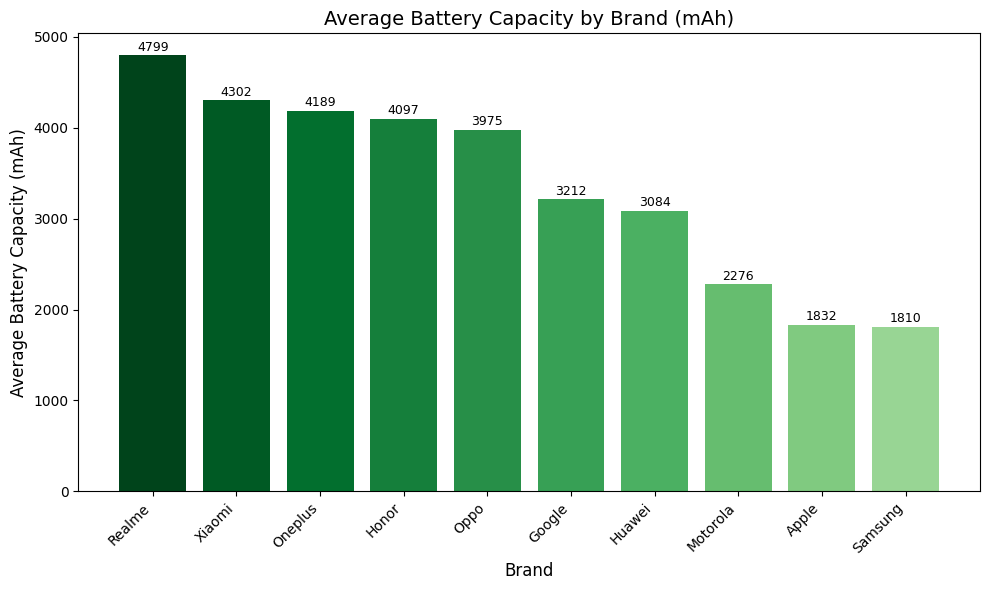

In [ ]:
# creating bar chart for battery capacity by brands
import matplotlib.pyplot as plt
import numpy as np

# Sort brands by battery capacity (optional)
battery_sorted = battery_by_brand.sort_values(by="battery", ascending=False)
battery_sorted.index = battery_sorted.index.str.title()

# Create gradient colors — darkest for largest battery
colors = plt.cm.Greens(np.linspace(1, 0.4, len(battery_sorted)))

# Plot bar chart
plt.figure(figsize=(10, 6))
plt.bar(battery_sorted.index, battery_sorted["battery"], color=colors)

# Add title and labels
plt.title("Average Battery Capacity by Brand (mAh)", fontsize=14)
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Average Battery Capacity (mAh)", fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels on top of bars
for i, v in enumerate(battery_sorted["battery"]):
    plt.text(i, v + 50, f"{int(v)}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Here we get the distribution of average battery capacity by the top brands in Germany, we can see that **Apple and Samsung** has the least average battery capacity.

### 3. Getting the top 10 brands with highest market share in Germany

In [ ]:
units_sold_dataframe = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Group Project/units_sold_eu_cleaned.csv")
units_sold_dataframe.head()

,Year,Month,Apple,Samsung,Xiaomi,Unknown,Huawei,Google,Motorola,Oppo,...,Nothing,TCL,Asus,Alcatel,Itel,Fairphone,CAT,T-Mobile,HTC,Other
0,2024,9,34.10,31.74,13.89,3.33,3.03,1.99,2.31,2.47,...,0.11,0.11,0.09,0.09,0.05,0.03,0.04,0.01,0.02,0.11
1,2024,10,36.50,31.14,12.95,3.27,2.82,2.08,2.21,2.36,...,0.11,0.10,0.08,0.08,0.05,0.03,0.03,0.01,0.02,0.08
2,2024,11,33.05,33.21,13.83,3.36,2.79,2.10,2.33,2.49,...,0.11,0.10,0.08,0.08,0.05,0.03,0.03,0.01,0.02,0.09
3,2024,12,33.36,33.16,13.54,3.51,2.74,2.13,2.37,2.36,...,0.12,0.09,0.08,0.07,0.05,0.04,0.03,0.01,0.02,0.08
4,2025,1,33.92,33.02,13.27,3.32,2.60,2.29,2.46,2.28,...,0.12,0.09,0.08,0.07,0.04,0.03,0.03,0.01,0.01,0.07


In [ ]:
brand_market_share = units_sold_dataframe.iloc[:, 2:].mean()
brand_market_share = brand_market_share.drop("Unknown")
brand_market_share

,0
Apple,34.436923
Samsung,32.610000
Xiaomi,12.510000
Huawei,2.506923
Google,2.582308
Motorola,2.418462
Oppo,2.236154
Realme,1.256923
Honor,1.196923
OnePlus,0.887692


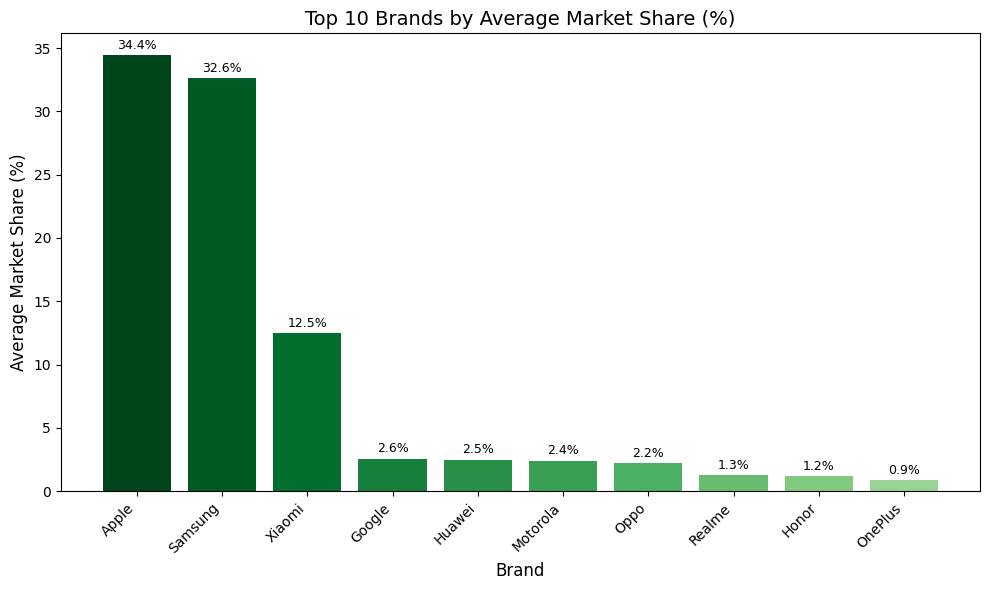

In [ ]:
# creating bar plot of brands' market share
brand_market_share = brand_market_share.sort_values(ascending=False)
import matplotlib.pyplot as plt
top_20_brands = brand_market_share.sort_values(ascending=False).head(10)

colors = plt.cm.Greens(np.linspace(1, 0.4, len(top_20_brands)))

# Create bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(top_20_brands.index, top_20_brands.values, color=colors)

# Add title and labels
plt.title("Top 10 Brands by Average Market Share (%)", fontsize=14)
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Average Market Share (%)", fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels on top of bars
for i, v in enumerate(top_20_brands.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Although, ***Apple and Samsung*** has the least Average Battery Capacity, they are the top 2 in the Average Market Share

### 4. Phone Usage by Age Group in Germany
From the ICT usage, amongst 3M rows, we filtered the internet usage of portable devices and mobile phones based on a few factors like age distributions from 16 to 75+ and their usage when outside their home Wi-Fi or Office or School Wi-Fi.

In [ ]:
phone_usage_clean = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Group Project/usage_eu_cleaned.csv")
phone_usage_clean

,indicator,unit,indicator_type,country,year,value,flag,value_missing,flag_missing
0,I_IUHD,PC_IND,CB_EU_FOR,AT,2012,34.110000,bu,0,1
1,I_IUHD,PC_IND,CB_EU_FOR,BE,2012,31.610000,bu,0,1
2,I_IUHD,PC_IND,CB_EU_FOR,BG,2012,40.062466,u,1,0
3,I_IUHD,PC_IND,CB_EU_FOR,CY,2012,16.340000,bu,0,1
4,I_IUHD,PC_IND,CB_EU_FOR,CZ,2012,40.062466,u,1,0
...,...,...,...,...,...,...,...,...,...
361260,I_IUMP,PC_IND_IU3,Y75_MAX,SK,2015,17.590000,u,0,0
361261,I_IUMP,PC_IND_IU3,Y75_MAX,SK,2016,5.760000,u,0,0
361262,I_IUMP,PC_IND_IU3,Y75_MAX,SK,2017,15.340000,u,0,0
361263,I_IUMP,PC_IND_IU3,Y75_MAX,UK,2011,1.230000,bu,0,1


In [ ]:
age_group = ["Y0_15","Y16_24","Y25_34","Y35_44","Y45_54","Y55_64","Y65_74","Y75_MAX"]
for_graph = phone_usage_clean[phone_usage_clean['country']== "DE"]
for_graph = for_graph[for_graph["indicator_type"].isin(age_group)]
for_graph

,indicator,unit,indicator_type,country,year,value,flag,value_missing,flag_missing
2007,I_IUHD,PC_IND,Y0_15,DE,2012,23.42,bu,0,1
2055,I_IUHD,PC_IND,Y16_24,DE,2012,51.34,bu,0,1
2434,I_IUHD,PC_IND,Y25_34,DE,2012,43.20,bu,0,1
2889,I_IUHD,PC_IND,Y35_44,DE,2012,27.40,bu,0,1
2927,I_IUHD,PC_IND,Y45_54,DE,2012,15.69,bu,0,1
...,...,...,...,...,...,...,...,...,...
360933,I_IUMP,PC_IND_IU3,Y65_74,DE,2017,49.89,bu,0,1
360934,I_IUMP,PC_IND_IU3,Y65_74,DE,2018,56.57,bu,0,1
360935,I_IUMP,PC_IND_IU3,Y65_74,DE,2019,45.86,bu,0,1
361225,I_IUMP,PC_IND_IU3,Y75_MAX,DE,2011,5.66,bu,0,1


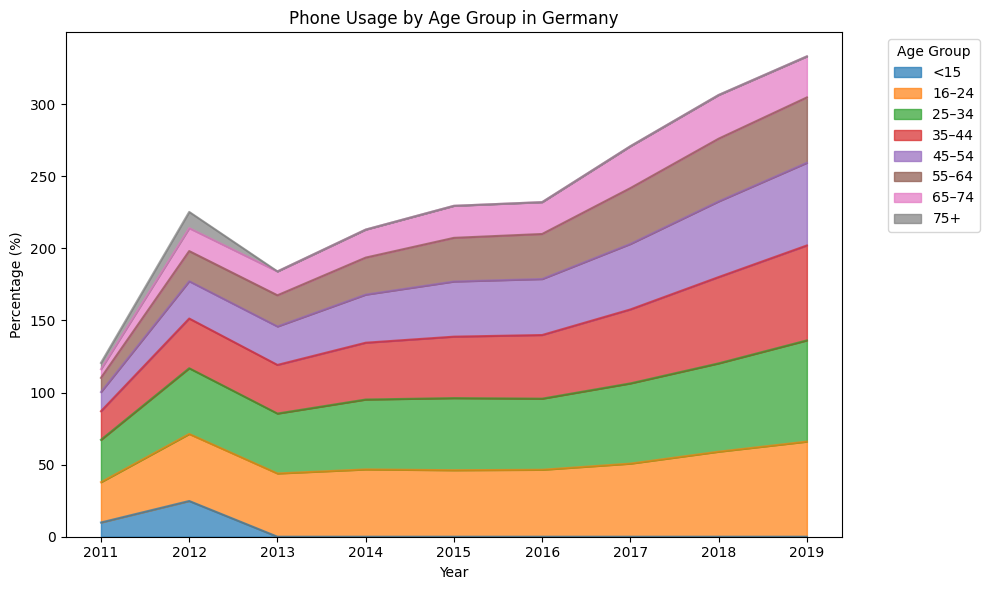

In [ ]:
# Make sure year is numeric
for_graph['year'] = pd.to_numeric(for_graph['year'], errors='coerce')

# Define readable age group labels
age_labels = {
    "Y0_15": "<15",
    "Y16_24": "16–24",
    "Y25_34": "25–34",
    "Y35_44": "35–44",
    "Y45_54": "45–54",
    "Y55_64": "55–64",
    "Y65_74": "65–74",
    "Y75_MAX": "75+"
}

# Pivot so each age group becomes a separate column
pivot_df = for_graph.pivot_table(index='year', columns='indicator_type', values='value', aggfunc='mean')

# Rename columns after pivoting
pivot_df = pivot_df.rename(columns=age_labels)

# Plot area chart
pivot_df.plot(kind='area', figsize=(10, 6), alpha=0.7)

plt.title('Phone Usage by Age Group in Germany')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

This shows that the usage of most Age group has almost tripled from 2011 to 2019 indicate the rise in usage of mobile phones.

### 5. Battery Capacity in Berlin

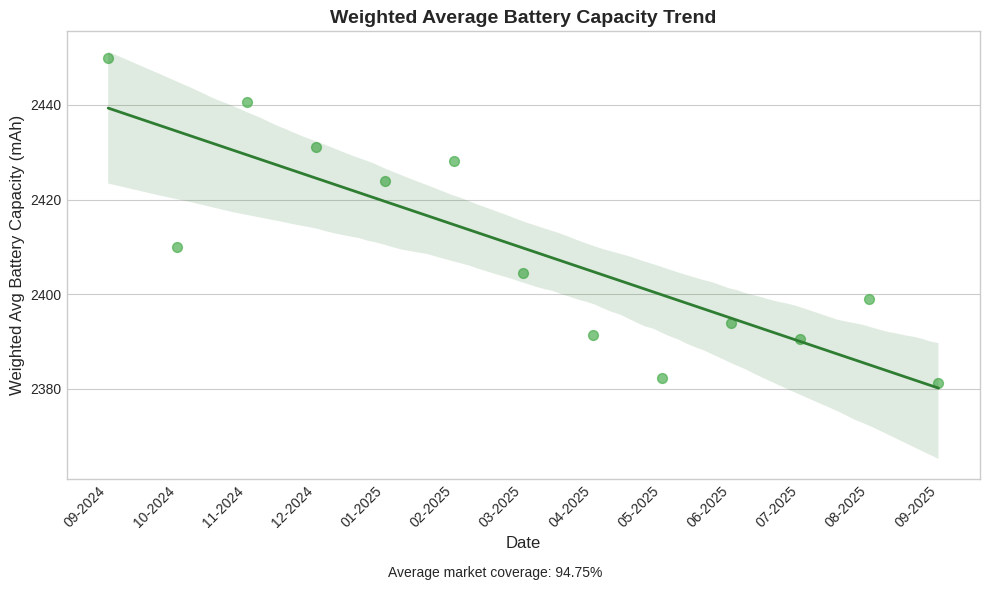

In [ ]:
# Visulaization of batter capacity in berlin
import matplotlib.pyplot as plt
import seaborn as sns


# Ensure 'Year' and 'Month' are integers for creating datetime objects
battery_results_dataframe['Year'] = battery_results_dataframe['Year'].astype(int)
battery_results_dataframe['Month'] = battery_results_dataframe['Month'].astype(int)

# Create a datetime object from 'Year' and 'Month'. Add a default day (e.g., 1) for a valid datetime.
battery_results_dataframe['Date'] = pd.to_datetime(battery_results_dataframe['Year'].astype(str) + '-' + battery_results_dataframe['Month'].astype(str) + '-01')


#  Create the numerical index for the regression (Time_Step)
battery_results_dataframe['Time_Step'] = np.arange(len(battery_results_dataframe))

# Create the 'Month_Year' string column for the tick labels
battery_results_dataframe['Month_Year'] = battery_results_dataframe['Date'].dt.strftime('%m-%Y')

plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

x_numeric = np.arange(len(battery_results_dataframe))

# 6. Use seaborn.regplot for the plot and regression line
sns.regplot(
    x=x_numeric,
    y='Weighted_Avg_Battery',
    data=battery_results_dataframe,
    ci=95,  # Show confidence interval band
    scatter_kws={'color': '#4CAF50', 's': 50, 'alpha': 0.7},
    line_kws={'color': '#2E7D32', 'linestyle': '-', 'linewidth': 2},
    color='#A5D6A7'
)

# 7. Customize the X-axis labels for readability
plt.xticks(
    ticks=x_numeric,
    labels=battery_results_dataframe['Month_Year'],
    rotation=45,
    ha='right'
)

plt.title('Weighted Average Battery Capacity Trend', fontsize=14, fontweight='bold')
plt.suptitle(f'Average market coverage: {battery_results_dataframe["Coverage_Percent"].mean():.2f}%', y=0, fontsize=10)
plt.ylabel('Weighted Avg Battery Capacity (mAh)', fontsize=12) # Add units to y-axis label
plt.xlabel('Date', fontsize=12)
plt.tight_layout()

plt.gca().xaxis.grid(False) # Remove x-grid

# 9. Save the plot
plt.savefig('battery_capacity_seaborn_regplot_minimal_green_ci.png')

### 6. Popular Locations


In [ ]:
!pip install contextily
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import googlemaps
import time
import math

GOOGLE_MAPS_API_KEY = ""

os.makedirs("./visuals", exist_ok=True)
visuals_path = "./visuals"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 68.8 MB/s eta 0:00:00


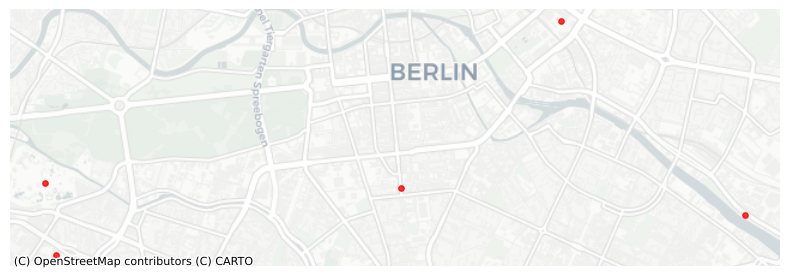

In [ ]:
# Load CSV
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Group Project/popular_places_berlin_all_thresholds.csv")

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lng, df.lat),
    crs="EPSG:4326"  # WGS84 (lat/lng)
)

# Convert to Web Mercator for contextily
gdf = gdf.to_crs(epsg=3857)

# Create static map
fig, ax = plt.subplots(figsize=(8, 8))

# Plot points (marker only, no labels)
gdf.plot(ax=ax, marker='.', color="r", markersize=60, alpha=0.8)

# Add basemap (using a stable provider)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Remove axes for clean presentation look
ax.set_axis_off()

# Tight layout for clean export
plt.tight_layout()

# Save as high-res PNG for presentation use
plt.savefig(os.path.join(visuals_path, "berlin_popular_locations_static_map.png"), dpi=300)
plt.show()

### 7. Competitors Locations

In [ ]:
"""
Modify competitors dataset to include coordinates.
Drop outliers.
"""

# Load the CSV
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Group Project/competitors.csv")

# Initialize Google Maps client with your API key
gmaps = googlemaps.Client(key=GOOGLE_MAPS_API_KEY)

# Reference point (Berlin center for example)
REF_LAT, REF_LNG = 52.5200, 13.4050  # Berlin coordinates

# Function to calculate distance between two lat/lng points in km
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)

    a = math.sin(delta_phi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(delta_lambda/2)**2
    c = 2*math.atan2(math.sqrt(a), math.sqrt(1-a))
    return R * c

# Function to geocode an address
def geocode_address(address):
    try:
        result = gmaps.geocode(address)
        if result:
            location = result[0]['geometry']['location']
            return location['lat'], location['lng']
        else:
            return None, None
    except Exception as e:
        print(f"Error geocoding {address}: {e}")
        return None, None

# Apply geocoding
df[['lat', 'lng']] = df['Address'].apply(lambda x: pd.Series(geocode_address(x)))

In [ ]:
# Filter out points more than 10 km from the reference
def filter_far(lat, lng):
    if pd.isna(lat) or pd.isna(lng):
        return False
    distance = haversine(REF_LAT, REF_LNG, lat, lng)
    return distance <= 7.5

df_filtered = df[df.apply(lambda row: filter_far(row['lat'], row['lng']), axis=1)]

# Save the filtered results
df_filtered.to_csv("./data/competitors/competitors_geocoded_filtered.csv", index=False)

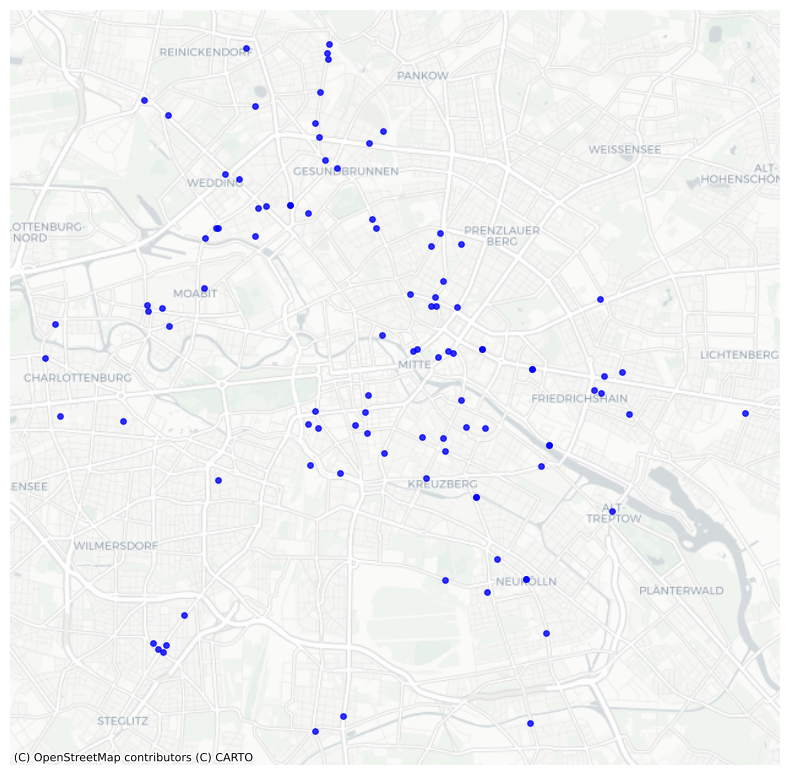

In [ ]:
# Load CSV
df = pd.read_csv("./data/competitors/competitors_geocoded_filtered.csv")

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lng, df.lat),
    crs="EPSG:4326"  # WGS84 (lat/lng)
)

# Convert to Web Mercator for contextily
gdf = gdf.to_crs(epsg=3857)

# Create static map
fig, ax = plt.subplots(figsize=(8, 8))

# Plot points (marker only, no labels)
gdf.plot(ax=ax, marker='.', color="b", markersize=60, alpha=0.8)

# Add basemap (using a stable provider)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Remove axes for clean presentation look
ax.set_axis_off()

# Tight layout for clean export
plt.tight_layout()

# Save as high-res PNG for presentation use
plt.savefig(os.path.join(visuals_path, "competitor_locations.png"), dpi=300)
plt.show()

### Overlapped Maps

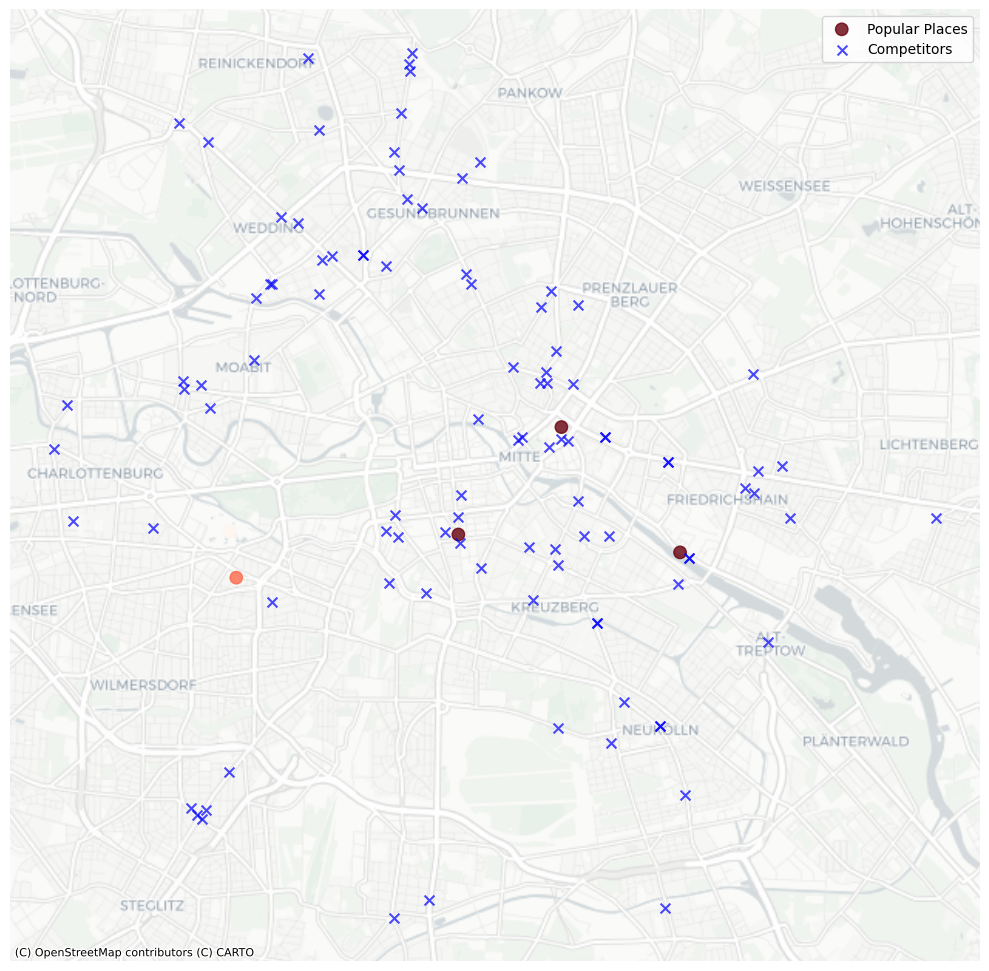

In [ ]:
# Load popular places
df_popular = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Group Project/popular_places_berlin_all_thresholds.csv")

# Compute a competition score (number of thresholds with competitor nearby)
competitor_cols = [col for col in df_popular.columns if col.startswith('has_competitor')]
df_popular['competition_score'] = df_popular[competitor_cols].sum(axis=1)

gdf_popular = gpd.GeoDataFrame(
    df_popular,
    geometry=gpd.points_from_xy(df_popular.lng, df_popular.lat),
    crs="EPSG:4326"
).to_crs(epsg=3857)

# Load competitors
df_competitors = pd.read_csv("./data/competitors/competitors_geocoded_filtered.csv")
gdf_competitors = gpd.GeoDataFrame(
    df_competitors,
    geometry=gpd.points_from_xy(df_competitors.lng, df_competitors.lat),
    crs="EPSG:4326"
).to_crs(epsg=3857)

# Plot map
fig, ax = plt.subplots(figsize=(10, 10))

# Plot popular places with color proportional to competition_score
gdf_popular.plot(
    ax=ax,
    marker='o',
    column='competition_score',
    cmap='Reds',
    markersize=80,
    legend=True,
    alpha=0.8,
    label='Popular Places'
)

# Plot competitors
gdf_competitors.plot(
    ax=ax,
    marker='x',
    color='blue',
    markersize=50,
    alpha=0.7,
    label='Competitors'
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(visuals_path, "berlin_competition_map.png"), dpi=300)
plt.show()

# Project Summary: Saturn PowerGo - Location Optimization in Berlin

This Jupyter Notebook documents the end-to-end data analysis project for the launch and strategic location optimization of **Saturn PowerGo Berlin**, a 24/7 power bank rental service operating in Germany's capital.

### Business Goal
To maximize our market penetration and return on investment by placing automated power bank stations in high-demand areas with low local competition.

### Methodology and Process

1.  **Business Setup (Section 01):** Defined the business model, operational strategy (24/7, year-round), and initial target city (Berlin).
2.  **Data Collection (Sections 02 & 03):** Collected necessary quantitative and qualitative data:
    * **Demand:** Used the Google Maps API to score popular places (tourist attractions, transit hubs, malls) by user rating and volume (a proxy for foot traffic).
    * **User Profile:** Analyzed Eurostat data on phone usage by age group to confirm the core 16-34 demographic.
    * **Device Specs:** Integrated Kaggle data on phone battery capacity (mAh) to model the user's need for charging.
    * **Competition:** Manually collected location data for key competitors in Berlin.
3.  **Data Processing & Cleaning (Section 04):** Cleaned, merged, and geo-processed all data sources to calculate a **'Competition Score'** for every high-demand location.
4.  **Final Recommendation (Section 05):** Generated a spatial map visualization (using Geopandas/Contextily) where demand is weighted against local competition, providing a clear visual guide for optimal station placement.

### Key Deliverable
A data-driven map identifying **greenfield opportunities** for expansion across Berlin's central districts.